## Imports

In [1]:
import random
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from pybeamline.mappers.print_operator import print_operator
from pybeamline.sources import BEvent
from river.drift import ADWIN, NoDrift

from models.streaming.darwin import DARWINRegressor
from models.streaming.sequence import LSTMModel, ProcessTransformerModel
from utils.streaming.base.emitters import RemainingTimeEmitter
from utils.streaming.base.learners import RemainingTimeLearner
from utils.streaming.base.maps import EmptyMap
from utils.streaming.base.pipelines import (
    BEventSource,
    PipelineMode,
    SourceMode,
    TaskPipeline,
)
from utils.streaming.base.predictors import PredictorMap
from utils.streaming.base.sinks import (
    EmptySink,
    RemainingTimeEvaluator,
)
from utils.streaming.base.transformers import (
    DARWINTimeTransformer,
    DARWINTransformer,
)
from utils.streaming.time import TimeTarget


## Numerical features

In [2]:
class TestPipeline(TaskPipeline):
    def __init__(
        self, model, transformer, end_events, target, predict_only=False
    ):

        super().__init__(
            model=model,
            transformer=transformer,
            end_events=end_events,
            pipeline_mode=PipelineMode.PREDICT_AND_LEARN,
            source_mode=SourceMode.BEVENTS,
        )

        self.predict_only = predict_only
        self.target = target

    def get_emitter(self):
        return RemainingTimeEmitter(
            self.transformer,
            end_events=self.end_events,
        )

    def get_predictor(self):
        return PredictorMap(self.model)

    def get_learner(self):
        return RemainingTimeLearner(self.model, target=self.target)
        return EmptyMap()

    def get_sink(self):
        return RemainingTimeEvaluator(target=self.target)
        return EmptySink()

    def run(self, bevents: list[BEvent]):
        source_obj = BEventSource()
        source = source_obj.get_source(bevents=bevents)

        emitter = self.get_emitter()
        predictor = self.get_predictor()
        learner = self.get_learner()
        sink = self.get_sink()

        source.pipe(
            emitter,
            predictor,
            print_operator(
                'PREDICT> trace_id={0[0]}, features={0[1]}, y_true={0[2]}, y_pred={0[3]}'
            ),
            learner if not self.predict_only else EmptyMap(),
        ).sink(sink)

        df = sink.to_dataframe()

        return df, self.model

In [11]:
# STATIC EVENT DURATIONS

EVENTS = [
    ('ABCDEF', 100),
    # ('ABE', 10),
]

PREDICT_EVENTS = [('ABCDEF', 1)]

# in days
EVENT_INTERVALS = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
}

# EVENT_INTERVALS = {
#     'A': 1,
#     'B': 1,
#     'C': 1,
#     'D': 1,
#     'E': 1,
#     'F': 1,
# }

bevents = []
predict_bevents = []
_case_id = 0
_case_start = datetime(2024, 1, 1, 8, 0, 0)

for trace, count in EVENTS:
    for _ in range(count):
        _case_id += 1

        for event in trace:
            bevents.append(BEvent(event, _case_id, 'Test process', _case_start))

            _case_start += timedelta(days=EVENT_INTERVALS.get(event, 0))

_case_id = 0
for trace, count in PREDICT_EVENTS:
    for _ in range(count):
        _case_id += 1

        for event in trace:
            predict_bevents.append(
                BEvent(event, f'unseen_{_case_id}', 'Test process', _case_start)
            )

            _case_start += timedelta(days=EVENT_INTERVALS.get(event, 0))


In [4]:
# PIECEWISE-LINEAR DURATIONS

NOISE_LEVEL = 0

EVENTS = [
    ('ABCDEF', 100),
    # ('AAAAAABCDEF', 100),
]

PREDICT_EVENTS = [('ABCDEF', 1)]

# in days
EVENT_INTERVALS = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
}


def get_piecewise_interval(
    event: str, prefix_position: int, noise_level: float
) -> float:
    if prefix_position < 2:
        base = EVENT_INTERVALS[event] * 0.75 + 0.25 * prefix_position
    elif prefix_position < 4:
        base = EVENT_INTERVALS[event] * 1.25 + 0.5 * prefix_position
    else:
        base = EVENT_INTERVALS[event] * 1.75 + 0.75 * prefix_position

    return max(0.0, base + random.gauss(0, noise_level))


bevents = []
predict_bevents = []
_case_id = 0
_case_start = datetime(2024, 1, 1, 8, 0, 0)

for trace, count in EVENTS:
    for _ in range(count):
        _case_id += 1
        prefix_position = 0

        for event in trace:
            bevents.append(BEvent(event, _case_id, 'Test process', _case_start))

            _case_start += timedelta(
                days=get_piecewise_interval(event, prefix_position, NOISE_LEVEL)
            )
            prefix_position += 1

_case_id = 0
for trace, count in PREDICT_EVENTS:
    for _ in range(count):
        _case_id += 1
        prefix_position = 0

        for event in trace:
            predict_bevents.append(
                BEvent(event, f'unseen_{_case_id}', 'Test process', _case_start)
            )

            _case_start += timedelta(
                days=get_piecewise_interval(event, prefix_position, NOISE_LEVEL)
            )
            prefix_position += 1


In [5]:
# CASE-SPECIFIC DIFFICULTY

NOISE_LEVEL = 0

EVENTS = [
    ('ABCDEF', 100),
]

PREDICT_EVENTS = [
    ('ABCDEF', 1),
]

# in days
EVENT_INTERVALS = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
}

CASE_DIFFICULTY = [0.5, 1.0, 2.0, 3.0]

def get_case_interval(event: str, case_difficulty: float) -> float:
    return EVENT_INTERVALS.get(event, 0) * case_difficulty

bevents = []
predict_bevents = []
_case_id = 0
_case_start = datetime(2024, 1, 1, 8, 0, 0)


for trace, count in EVENTS:
    for _ in range(count):
        _case_id += 1

        case_difficulty = CASE_DIFFICULTY[_case_id % len(CASE_DIFFICULTY)]

        for event in trace:
            bevents.append(BEvent(event, _case_id, 'Test process', _case_start))

            _case_start += timedelta(days=get_case_interval(event, case_difficulty))

_case_id = 0
for trace, count in PREDICT_EVENTS:
    for _ in range(count):
        _case_id += 1

        case_difficulty = CASE_DIFFICULTY[_case_id % len(CASE_DIFFICULTY)]

        for event in trace:
            predict_bevents.append(
                BEvent(event, f'unseen_{_case_id}', 'Test process', _case_start)
            )

            _case_start += timedelta(days=get_case_interval(event, case_difficulty))


In [6]:
unique_events = {event for trace, count in EVENTS for event in trace}
end_events = {event for trace, count in EVENTS for event in trace[-1]}

unique_events = {event for trace, count in EVENTS for event in trace}
end_events = {event for trace, count in EVENTS for event in trace[-1]}
num_events = sum(count * len(trace) for trace, count in EVENTS)

print(f'Unique events: {unique_events}')
print(f'End events: {end_events}')
print(f'Number of events: {num_events}')

Unique events: {'E', 'F', 'B', 'D', 'C', 'A'}
End events: {'F'}
Number of events: 600


In [17]:
# darwin_transformer = DARWINTimeTransformer()
# feature_size = 2

darwin_transformer = DARWINTransformer()
feature_size = 0

embedding_dim = 4

sequence_window = 4

darwin_model = DARWINRegressor(
    embedding_dim=embedding_dim,
    w2v_window=5,
    sequence_window=sequence_window,
    optimizer_cls=lambda p: optim.NAdam(p, lr=0.1),
    loss_fn=nn.MSELoss(),
    # sequence_model=LSTMModel(
    #     input_dim=embedding_dim + feature_size,
    #     hidden_dim=32,
    #     num_layers=1,
    #     dropout=0.01,
    # ),
    sequence_model=ProcessTransformerModel(
        input_dim=embedding_dim + feature_size,
        head_dim=32,
        num_heads=4,
        num_layers=1,
        dropout=0.01,
        max_len=sequence_window,
        pooling_dropout=0.1,
        pooling_type='max'
    ),
    batch_size=32,
    epochs=100,
    init_size=int(num_events * 0.1),
    end_events=end_events,
    drift_detector=NoDrift(),
    feature_size=feature_size,
)

pipeline = TestPipeline(
    model=darwin_model,
    transformer=darwin_transformer,
    target=TimeTarget.DAYS,
    end_events=end_events,
)
darwin_results_df, darwin_model = pipeline.run(bevents)

PREDICT> trace_id=1, features={'case_id': 1, 'event_id': 1, 'event_name': 'A', 'features': []}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event_id': 2, 'event_name': 'B', 'features': []}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event_id': 3, 'event_name': 'C', 'features': []}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event_id': 4, 'event_name': 'D', 'features': []}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event_id': 5, 'event_name': 'E', 'features': []}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={}, y_true=2024-01-16 08:00:00, y_pred=None
PREDICT> trace_id=2, features={'case_id': 2, 'event_id': 7, 'event_name': 'A', 'features': []}, y_true=None, y_pred=None
PREDICT> trace_id=2, features={'case_id': 2, 'event_id': 8, 'event_name': 'B', 'features': []}, y_true=None, y_pred=None
PREDICT> trace_id=2, features={'case_id': 2, 'event_id': 9, 'event_name': 'C', 

In [8]:
darwin_results_df.tail(20)

,trace_id,trace_n,event_n,y_true,y_pred,n_pred,n_drifts,drift_detected,prefix_len,loss,mae,rmse
480,97,97,577,15.0,23.785219,421,0,False,1,57.370249,4.506850,7.508362
481,97,97,578,14.0,14.913477,422,0,False,2,57.370249,4.498335,7.499592
482,97,97,579,12.0,9.546618,423,0,False,3,57.370249,4.493501,7.491672
483,97,97,580,9.0,8.907881,424,0,False,4,57.370249,4.483120,7.482833
484,97,97,581,5.0,4.811136,425,0,False,5,57.370249,4.473016,7.474030
485,98,98,583,30.0,23.785219,426,0,False,1,57.370249,4.477105,7.471323
486,98,98,584,28.0,25.205812,427,0,False,2,57.370249,4.473164,7.463794
487,98,98,585,24.0,24.006775,428,0,False,3,57.370249,4.462728,7.455070
488,98,98,586,18.0,17.850273,429,0,False,4,57.370249,4.452675,7.446379
489,98,98,587,10.0,10.586854,430,0,False,5,57.370249,4.443684,7.437770


In [9]:
darwin_predict_pipeline = TestPipeline(
    model=darwin_model,
    transformer=darwin_transformer,
    target=TimeTarget.DAYS,
    end_events=end_events,
    predict_only=True,
)
darwin_predict_results_df, _ = darwin_predict_pipeline.run(predict_bevents)

PREDICT> trace_id=unseen_1, features={'case_id': 'unseen_1', 'event_id': 601, 'event_name': 'A', 'features': [0.0, 0.0]}, y_true=None, y_pred=23.785219192504883
PREDICT> trace_id=unseen_1, features={'case_id': 'unseen_1', 'event_id': 602, 'event_name': 'B', 'features': [1.0, 1.0]}, y_true=None, y_pred=14.913476943969727
PREDICT> trace_id=unseen_1, features={'case_id': 'unseen_1', 'event_id': 603, 'event_name': 'C', 'features': [3.0, 2.0]}, y_true=None, y_pred=9.546618461608887
PREDICT> trace_id=unseen_1, features={'case_id': 'unseen_1', 'event_id': 604, 'event_name': 'D', 'features': [6.0, 3.0]}, y_true=None, y_pred=8.907880783081055
PREDICT> trace_id=unseen_1, features={'case_id': 'unseen_1', 'event_id': 605, 'event_name': 'E', 'features': [10.0, 4.0]}, y_true=None, y_pred=4.811136245727539
PREDICT> trace_id=unseen_1, features={}, y_true=2033-05-20 20:00:00, y_pred=None


In [10]:
darwin_predict_results_df

,trace_id,trace_n,event_n,y_true,y_pred,n_pred,n_drifts,drift_detected,prefix_len,loss,mae,rmse
0,unseen_1,1,1,15.0,24.202333,1,0,False,1,42.908186,9.202333,9.202333
1,unseen_1,1,2,14.0,11.827437,2,0,False,2,42.908186,5.687448,6.685917
2,unseen_1,1,3,12.0,11.717452,3,0,False,3,42.908186,3.885815,5.461465
3,unseen_1,1,4,9.0,8.883575,4,0,False,4,42.908186,2.943467,4.730126
4,unseen_1,1,5,5.0,4.844703,5,0,False,5,42.908186,2.385833,4.231323


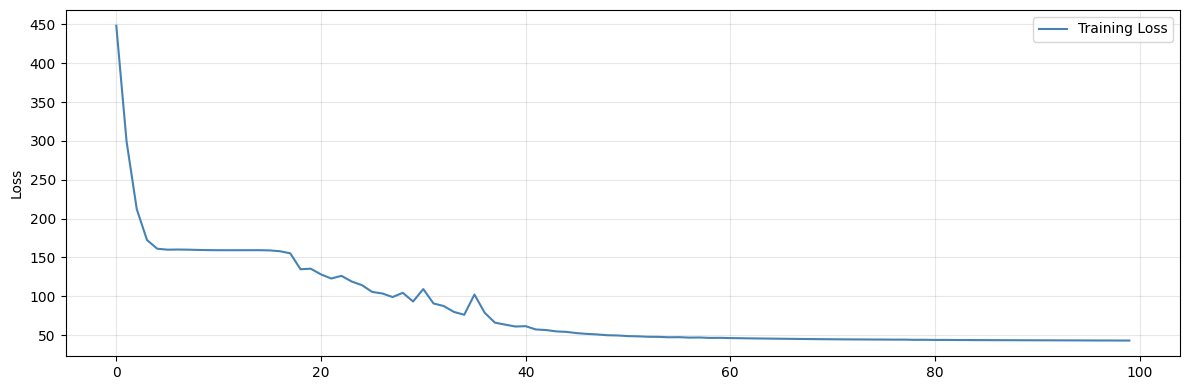

In [11]:
if hasattr(darwin_model, 'loss_history'):
    _, ax = plt.subplots(figsize=(12, 4))

    ax.plot(
        darwin_model.loss_history,
        label='Training Loss',
        color='steelblue',
        linewidth=1.5,
    )
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')
    ax.set_ylabel('Loss')
    ax.legend(loc='best')

    plt.tight_layout()